# Vizualizacija podataka - Matplotlib

Čovjek puno lakše čita grafičke prikaze podataka, nego sirove podatke, npr. u tablici. Do sada smo se bavili tabličnim prikazom podataka pa je vrijeme za prikaz podataka u obliku grafova.

Python ima jako puno biblioteka koje mogu grafički prikazati podatke, ali se za potrebe analize podataka (podatkovne znanosti), *matplotlib* pokazao kao jedna od najboljih. Matplotlib je (više detalja na stranici: https://matplotlib.org/) Python biblioteka namijenjena za grafički prikaz podataka. Standardni je dio Anaconda distribucije, a naravno, može se instalirati zasebno.

Službena stranica Matplotlib biblioteke navodi glavne karakteristike zašto koristiti biblioteku:

- Stvaranje visokokvalitetnih vizualnih prikaza - za pisanje znanstvenih članaka
- Interaktivni prikazi koji se mogu uvećavati, pomicati i mjenjati.
- Prilagođavanje stila i izgleda grafova.
- Spremnaje grafova u različite formate.
- Integracija s Jupyter Notebookom
- Puno ostalih paketa je izrađeno na temelju Matplotlib biblioteke

Najbolji način da se upoznamo s bibliotekom je kroz primjere.



In [1]:
import matplotlib.pyplot as plt # Ucitavanje biblioteke tj. modula pyplot
import pandas as pd

# Sad cemo nauciti jos jedan nacin parsiranja datuma
casedistribution = pd.read_csv('casedistribution.csv', parse_dates=['dateRep']) 

casedistribution

,dateRep,day,month,year,cases,deaths,countriesAndTerritories,geoId,countryterritoryCode,popData2019,continentExp,Cumulative_number_for_14_days_of_COVID-19_cases_per_100000
0,2020-12-14,14,12,2020,746,6,Afghanistan,AF,AFG,38041757.0,Asia,9.013779
1,2020-12-13,13,12,2020,298,9,Afghanistan,AF,AFG,38041757.0,Asia,7.052776
2,2020-12-12,12,12,2020,113,11,Afghanistan,AF,AFG,38041757.0,Asia,6.868768
3,2020-11-12,11,12,2020,63,10,Afghanistan,AF,AFG,38041757.0,Asia,7.134266
4,2020-10-12,10,12,2020,202,16,Afghanistan,AF,AFG,38041757.0,Asia,6.968658
...,...,...,...,...,...,...,...,...,...,...,...,...
61895,2020-03-25,25,3,2020,0,0,Zimbabwe,ZW,ZWE,14645473.0,Africa,NaN
61896,2020-03-24,24,3,2020,0,1,Zimbabwe,ZW,ZWE,14645473.0,Africa,NaN
61897,2020-03-23,23,3,2020,0,0,Zimbabwe,ZW,ZWE,14645473.0,Africa,NaN
61898,2020-03-22,22,3,2020,1,0,Zimbabwe,ZW,ZWE,14645473.0,Africa,NaN


In [2]:
casedistribution.columns # Proucimo koje stupce smo ucitali

Index(['dateRep', 'day', 'month', 'year', 'cases', 'deaths',
       'countriesAndTerritories', 'geoId', 'countryterritoryCode',
       'popData2019', 'continentExp',
       'Cumulative_number_for_14_days_of_COVID-19_cases_per_100000'],
      dtype='object')

Kako imamo za različita područja podatke po datumima, za početak grupiramo podatke po datumu, na način da će nam agregacijska funkcija biti suma (zbrajanje). Zbrojimo ukupni broj slučajeva u danu.

In [3]:
cases_per_day = casedistribution[['dateRep', 'cases']].groupby('dateRep', as_index=False).sum()
cases_per_day.sort_values(by='dateRep', inplace=True) # Sortiramo po datumu
cases_per_day

,dateRep,cases
0,2019-12-31,27
1,2020-01-01,0
2,2020-01-02,2121
3,2020-01-03,1843
4,2020-01-04,74847
...,...,...
345,2020-12-10,304057
346,2020-12-11,623511
347,2020-12-12,657140
348,2020-12-13,626421


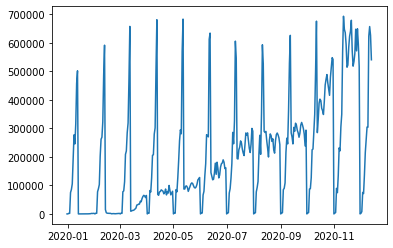

In [4]:
plt.plot(cases_per_day.dateRep, cases_per_day.cases) # Iscrtavanje

Uobičajeno je prikazivati graf pomoću `plt.show()`, ali isto kao i za funkciju `print`, Jupyter Notebook to automatski napravi za vas.

Graf možemo prikazati i drugim stilovima, pogledajmo za početak jedan primjer. Nakon toga pokazati ćemo druge mogućnosti sa stilovima. Stil se piše s kodom [marker][linija][boja]. Marker će biti prikazan na točnoj vrijednosti. Dvije vrijednosti povezuje linija.

U ovom slučaju uzet ćemo točkastu liniju i boja magenta, marker ignoriramo.

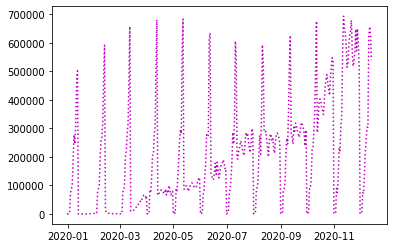

In [5]:
plt.plot(cases_per_day.dateRep, cases_per_day.cases, ':m')

Evo još nekih primjera:
|Marker|Stil linije|Boja|Format|Rezultat|
|------|-----------|----|------|--------|
| |-|b|-b|plava puna linija|
|.||k|.k|crne točke|
| |--|r|--r|crvena isprekidana linija|
|o|-|g|o-g|zelena puna linija s kružićima|
| |:|m|:m|magenta točkasta linija|
|x|-.|c|x-.c|ljubičasta (cyan) crta-točka linija s x-ićima|

Detalje možete naći na stranici: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html

1. Vježba

Prikažite isti graf, samo za zelenim kružićima u isprekidanoj liniji.

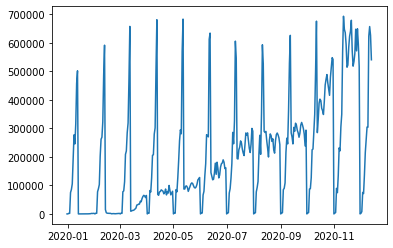

In [6]:
plt.plot(cases_per_day.dateRep, cases_per_day.cases, '') # TODO

Okvir u kojem je prikazan graf predstavlja objekt koji se zove *figure* (više detalja na: https://matplotlib.org/stable/api/figure_api.html#module-matplotlib.figure). 

Prvo ćemo pokazati kako globalno promjeniti parametre prikaza.

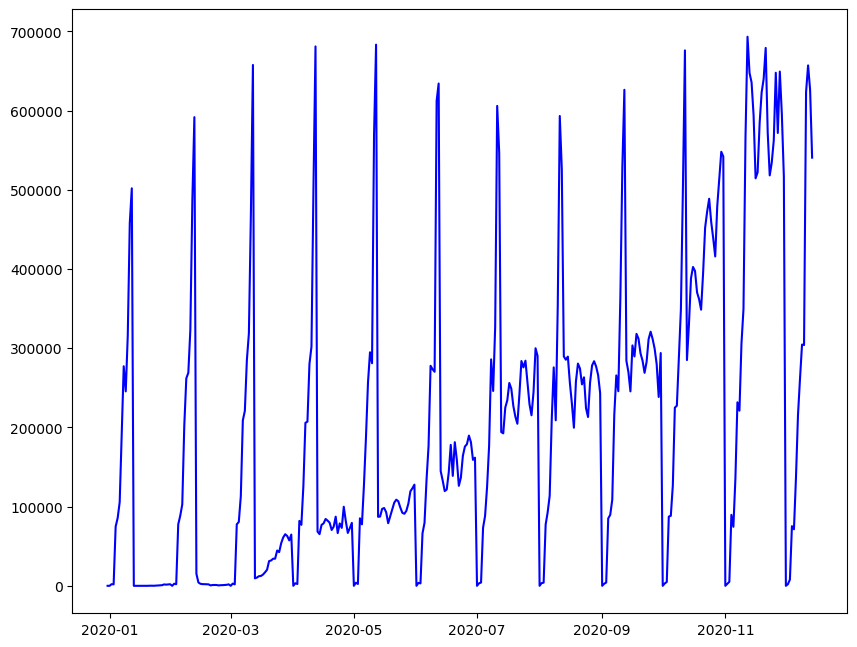

In [7]:
plt.rcParams['figure.figsize'] = [10, 8] # Podesit cemo sirinu i visinu okvira
plt.rcParams['figure.dpi'] = 100 # gustocu prikaza dpi = dots per inch

plt.plot(cases_per_day.dateRep, cases_per_day.cases, '-b')

In [8]:
plt.rcdefaults() # Postavimo globalne postavke na default

## Figure objekt

Figure objekt je središnji objekt prilikom iscrtavanja. Figure je sačinjen od više komponenti koje se mogu prilagoditi. Više detalja možete pronaći na: https://matplotlib.org/stable/gallery/showcase/anatomy.html

*Figure* objekt možemo kreirati izravno i u njega naknadno dodavati elemente. Matplotlib za kreiranje *Figure* objekta ima *figure()* metodu. Pogledajmo kako radi i što sve možemo s *Figure* objektom. Kreirat ćemo jedan objekt naziva "okvir".

In [9]:
okvir = plt.figure()

<Figure size 640x480 with 0 Axes>

Kreirati ćemo objekt Figure s veličinom (u inčima).
Nakon toga kreiramo vanjski graf. Argumenti su (left, bottom, width, height).
A onda i unutarnji graf.

Arugumenti su zadani kao djelovi ukupne visine i širine objekta Figure. Npr. 0.1 znači 10% od veličine.

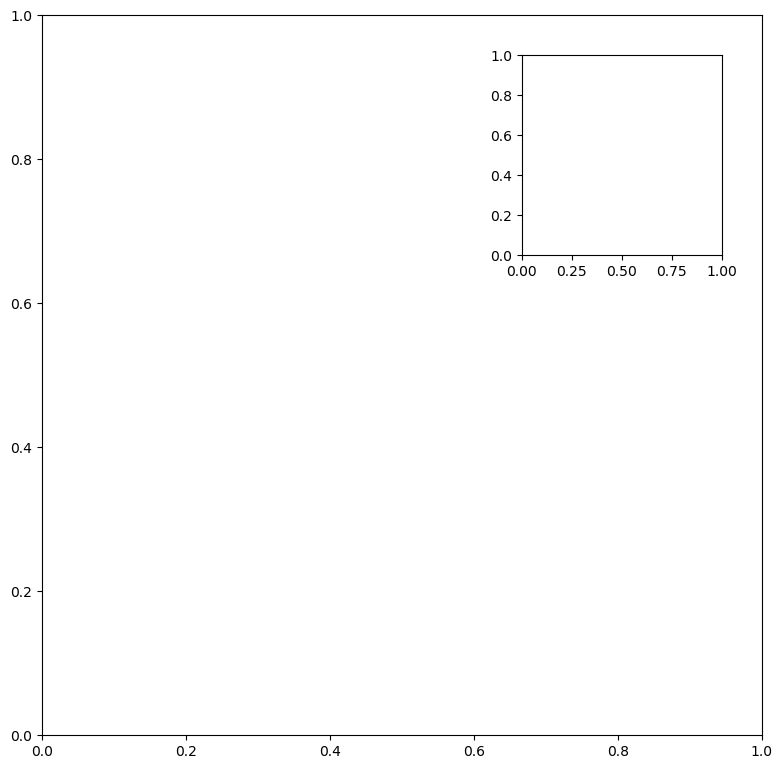

In [10]:
okvir = plt.figure(figsize=(8,8))
vanjski_graf = okvir.add_axes((0.1,0.1, 0.9, 0.9))
unutarnji_graf = okvir.add_axes((0.7,0.7, 0.25, 0.25))

2. Vježba

**Promjenom parametara metode add_axes(), pozicionirajte unutarnji okvir u:**
- **gornji lijevi kut**
- **donji lijevi kut**
- **sredinu**

Isto tako, unutar okvira možemo definirati mrežu kolona i redova (kao tabela) te unutar njih dodavati grafove, bolje rečeno podgrafove.

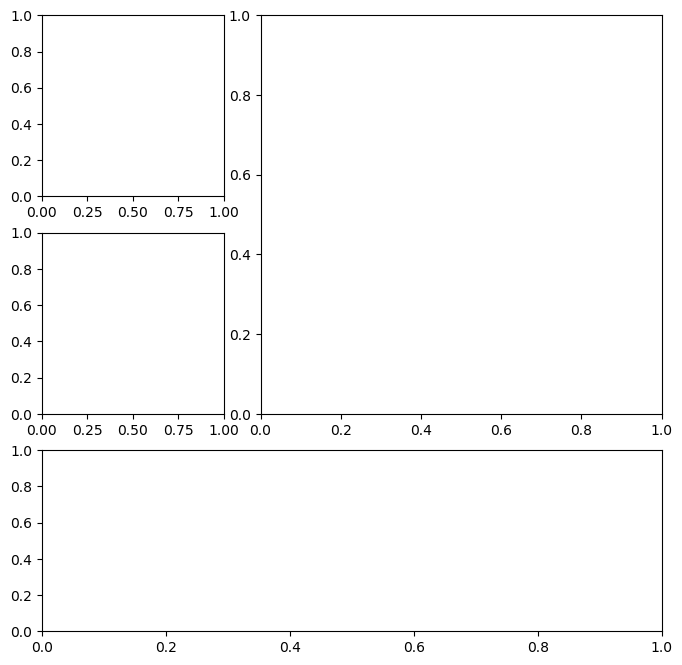

In [11]:
okvir = plt.figure(figsize=(8, 8)) # figsize 
gs = okvir.add_gridspec(3, 3) # postavke mreze -> 3 stupca, tri reda

# PAZNJA - indeksi pocinju s bojem 0
gore_lijevo = okvir.add_subplot(gs[0, 0]) # zauzima prvi red i prvi stupac
sredina_lijevo = okvir.add_subplot(gs[1, 0]) # zauzima drugi red i prvi stupac
gore_desno = okvir.add_subplot(gs[:2, 1:]) # zauzima prva dva reda od 0 do 2 te sve stupce pocevsi od drugog
dolje = okvir.add_subplot(gs[2,:]) # zauzima treci red i sve stupce

Već smo spomenuli podokvire te jedan okvir unutar drugog i sl. To možemo napraviti tijekom inicijalizacije pa tako možemo okvir podijeliti na redove i kolone te odmah definirati i osi. Pomoću *plt.subplot()* metode kreirat ćemo broj redova (prvi argument) i broj stupaca (drugi argument).

Kreirat ćemo jedan veliki okvir, u kojemu će biti dvije kolone i jedan red.

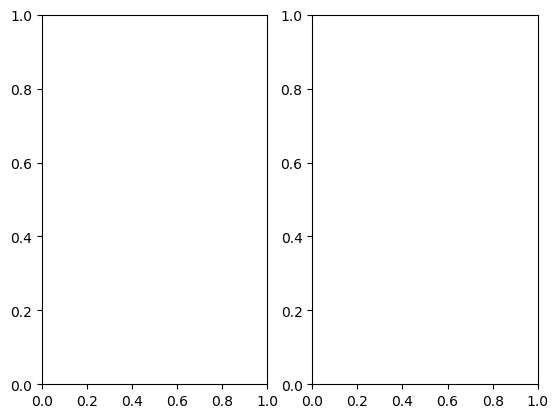

In [12]:
okvir, osi = plt.subplots(1, 2)

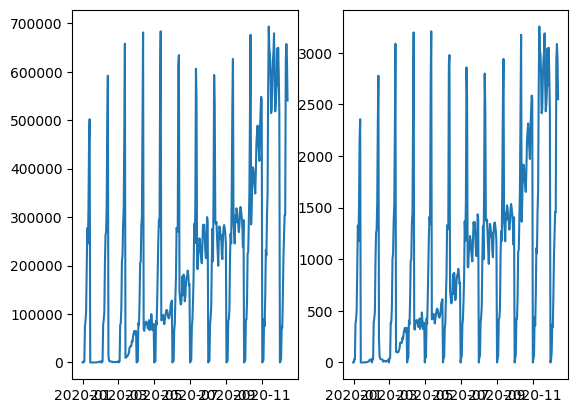

In [13]:
cases_per_day_mean = casedistribution[['dateRep', 'cases']].groupby('dateRep', as_index=False).mean()
cases_per_day_mean.sort_values(by='dateRep', inplace=True) # Sortiramo po datumu

osi[0].plot(cases_per_day.dateRep, cases_per_day.cases)
osi[1].plot(cases_per_day_mean.dateRep, cases_per_day_mean.cases)
okvir

# Podrška unutar Pandas biblioteke

Već smo se upoznali s Pandas bibliotekom i  spomenuli da je ta biblioteka razvijena na NumPy biblioteci, što znači da ona koristi tu biblioteku za svoj rad. Spomenuli smo i da Pandas za oba tipa objekata (*Serise i DataFrame*) ima ugrađenu *plot()* metodu. Pandas *.plot()* metoda u pozadini koristi matplotlib biblioteku.
Više detalja na: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html.

Neki od najčešće korištenih argumenata Pandas *.plot()* metode:
- *kind* - definira tip grafa - *string*
- *x* ili *y* - definira jednu ili više kolona koje će biti na navedenoj osi - *string* ili lista *stringova*
- *subplots* - pomoću *Boolean* uključuje ili ne uključuje dodatne grafove
- *layout* - pomoću redova, kolona definira broj dodatnih grafova
- *figsize* - pomoću širina, visina definira veličinu okvira
- *title* - definira naslov grafa - *string*
- *grid* - pomoću *Boolean* varijable uključuje linije mreže
- *color* - pomoću r, g, b (crvene, zelene, plave) definira boju grafa.

Argumenata ima jako puno pa je najbolje da krenemo s primjerima kako bismo se upoznali s mogućnostima.

Dodat ćemo novi skup podataka kako bismo lakše opisali neke funkcionalnosti. Koristit ćemo podatke o ocjenama korisnika trgovačkog lanca "mall_customers.csv".

In [14]:
mall_customers = pd.read_csv('mall_customers.csv')
mall_customers

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


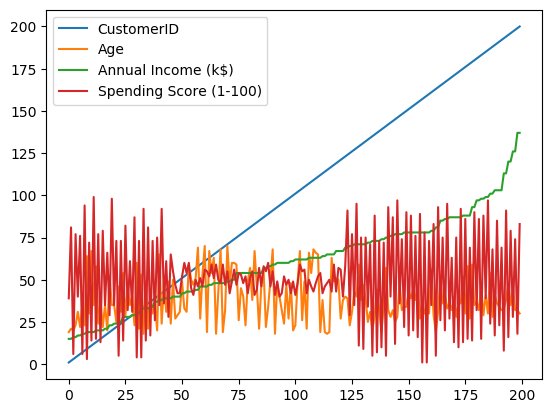

In [15]:
mall_customers.plot()

Ovakav graf trenutno nam nije koristan. Idemo probati pomoću primjera iskoristiti parametre koje smo spomenuli.

In [16]:
customers_score = mall_customers.iloc[:, [1, 2, 4]]
customers_score

,Gender,Age,Spending Score (1-100)
0,Male,19,39
1,Male,21,81
2,Female,20,6
3,Female,23,77
4,Female,31,40
...,...,...,...
195,Female,35,79
196,Female,45,28
197,Male,32,74
198,Male,32,18


Iscrtajmo vezu između godina i prosječnog bodovanja.

Prvo grupiramo podatke i izračunavamo srednju vrjednost.
Nakon toga iskoristiti ćemo parametre kako bi prikazali ono što želimo.

In [17]:
mean_by_age = customers_score.groupby(by='Age',as_index=False).mean()
mean_by_age

,Age,Spending Score (1-100)
0,18,60.000000
1,19,39.750000
2,20,40.200000
3,21,66.800000
4,22,70.000000
5,23,63.333333
6,24,71.500000
7,25,39.666667
8,26,54.500000
9,27,60.333333


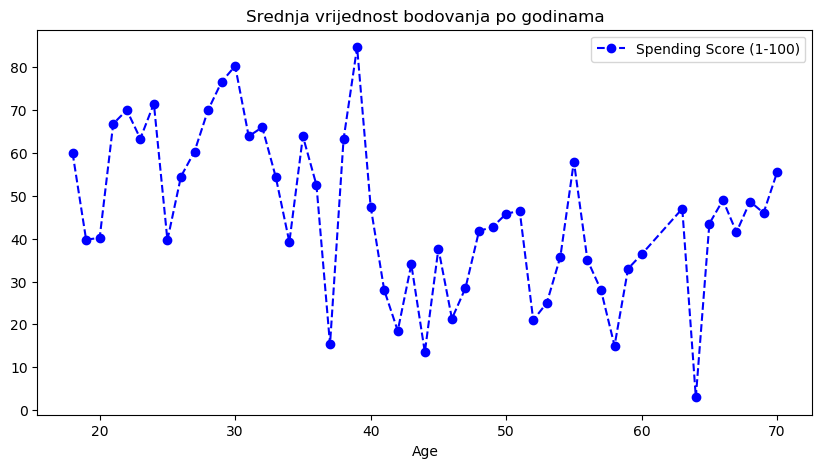

In [18]:
mean_by_age.plot(
    kind='line', # tip grafa
    x='Age', # podaci za x-os
    y='Spending Score (1-100)', # podaci za y-os
    figsize=(10, 5), # velicina okvira u incima
    style='o--b', # format stila, ovisno i o tipu
    legend=True, # prikaz legende
    title='Srednja vrijednost bodovanja po godinama' # naslov
)

3. Vježba

Pomoću dosadašnjeg znanja, napravite jedan Figure objekt koji sadrži dva grafa. Jedan koji pokazuje potrošački score po godinama za mušku i drugi koji pokazuje za žensku populaciju.

In [19]:
# TODO

Iscrtajmo sad na jednom grafu prihode i potrošački score.
Obratimo pažnju kako odabiremo y os i stil za osi.

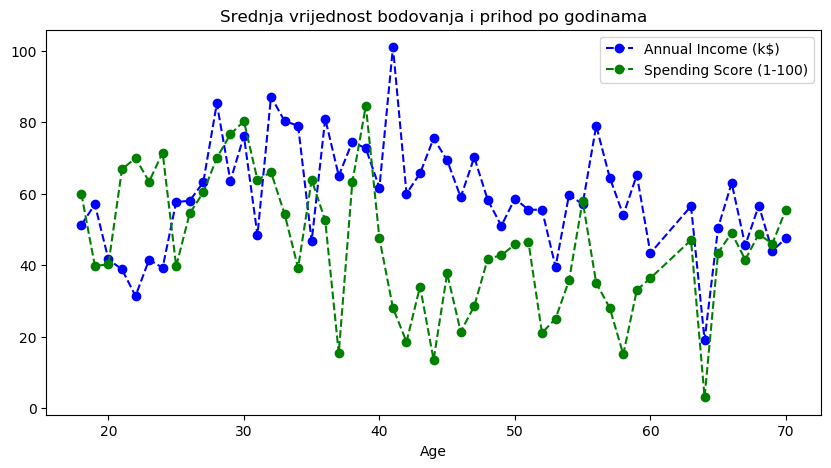

In [20]:
mall_customers.groupby(by='Age', as_index=False).mean().plot(
    kind='line', # tip grafa
    x='Age', # podaci za x-os
    y=['Annual Income (k$)', 'Spending Score (1-100)'], # podaci za y-os
    figsize=(10, 5), # velicina okvira u incima
    style=['o--b', 'o--g'], # format stila, ovisno i o tipu
    legend=True, # prikaz legende
    title='Srednja vrijednost bodovanja i prihod po godinama' # naslov
)

Pogledajmo kako pomoću pandasa možemo iscrtati dva grafa jedan pored drugog.

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x00000292B68EE588>,
      dtype=object)

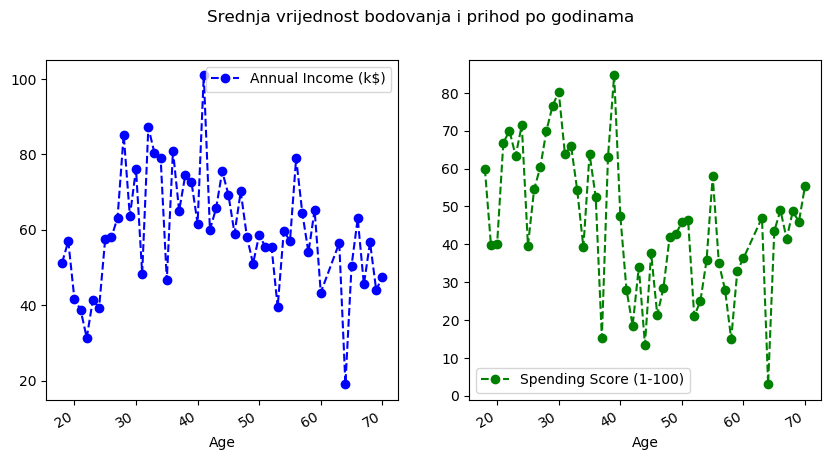

In [21]:
mall_customers.groupby(by='Age', as_index=False).mean().plot(
    kind='line', # tip grafa
    x='Age', # podaci za x-os
    y=['Annual Income (k$)', 'Spending Score (1-100)'], # podaci za y-os
    subplots=True, # Vise plotova
    layout=(1, 2), # jedan red, dva stupca
    figsize=(10, 5), # velicina okvira u incima
    style=['o--b', 'o--g'], # format stila, ovisno i o tipu
    legend=True, # prikaz legende
    title='Srednja vrijednost bodovanja i prihod po godinama' # naslov
)

Pokažimo još jedan način kako napraviti dva grafa na jednoj slici.
Ovdje ćemo obraditi podatke pomoću `pivot_table` i `rolling`.

Više detalja za `rolling`: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rolling.html

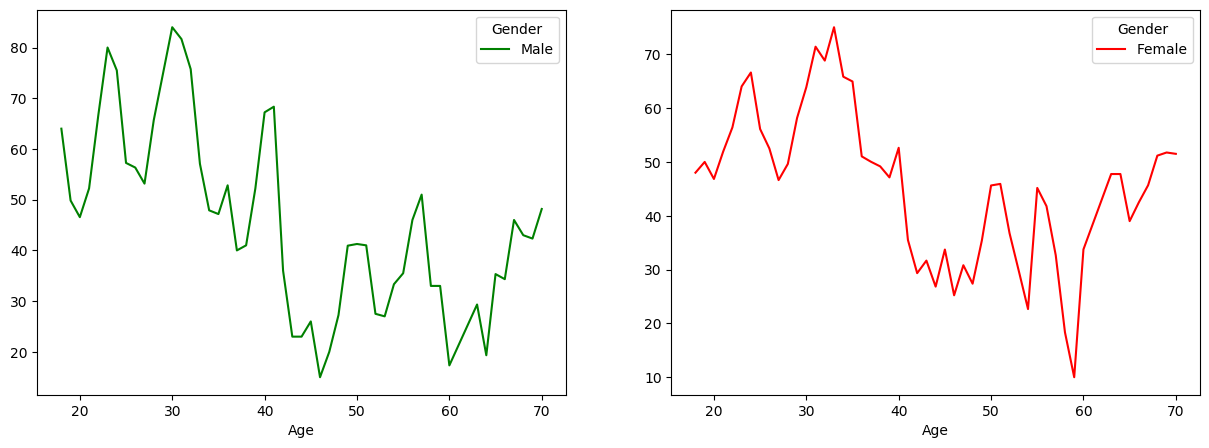

In [22]:
cutomers_by_age_gender = mall_customers[['Gender', 'Age', 'Spending Score (1-100)']]
cutomers_by_age_gender = cutomers_by_age_gender.pivot_table(index='Age', columns='Gender', values='Spending Score (1-100)', aggfunc='mean')
cutomers_by_age_gender = cutomers_by_age_gender.rolling(3, min_periods=1).mean() # Grupiramo u prozoru od 3

okvir, osi = plt.subplots(1, 2, figsize=(15, 5))

cutomers_by_age_gender[['Male']].plot(ax=osi[0], color='g')
cutomers_by_age_gender[['Female']].plot(ax=osi[1], color='r')


Probajmo iscrtati druge tipove grafova. Za početak želimo iscrtati samo točke koje predstavljaju podatke. Iscrtat ćemo vezu prihoda i potraščkog score-a.

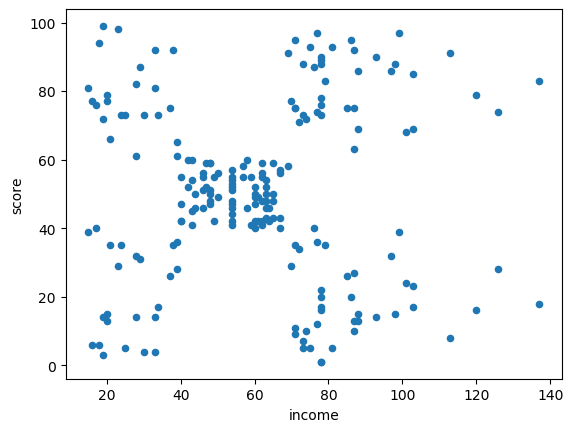

In [23]:
income_and_score = mall_customers.iloc[:, [3, 4]]
income_and_score.columns = ['income', 'score'] # Nova imena stupaca
income_and_score.plot(kind='scatter', x='income', y='score')

Pokušajmo isto napraviti i za skup podataka ocjene. Proučavamo koliko sati je potrošeno na učenje i ocjena.

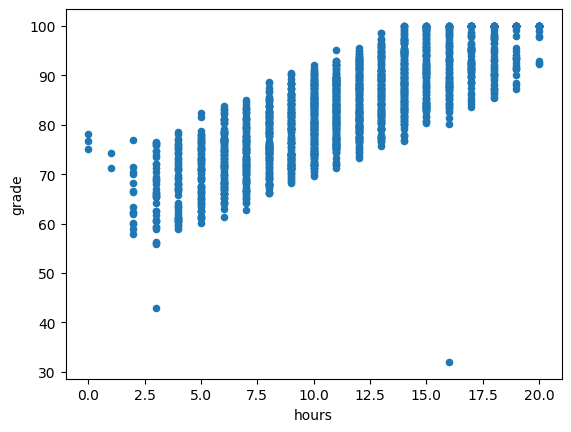

In [24]:
ocjene = pd.read_csv('ocjene.csv')[['hours', 'grade']]
ocjene.plot(kind='scatter', x='hours', y='grade')

Ovdje možemo uočiti jaku pravilnost!

Provjerimo izračunavanjem korelacije, koliko ona iznosi.

In [25]:
ocjene.corr()

,hours,grade
hours,1.000000,0.801955
grade,0.801955,1.000000


4. Vježba

Iscrtajte dva grafa s vezom sati učenja i ocjenama po spolovima. Neka budu na istoj slici (Figure).

Napravimo histogram prihoda.

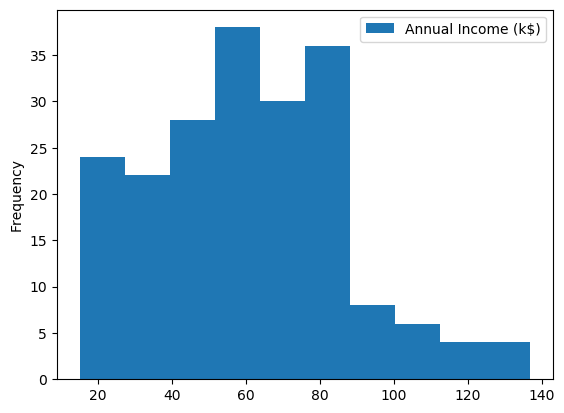

In [26]:
age_income = mall_customers.iloc[:, [3]]
age_income.plot(kind='hist')

Kod histograma možemo podesiti broj stupaca (bins) po kojima brojimo.

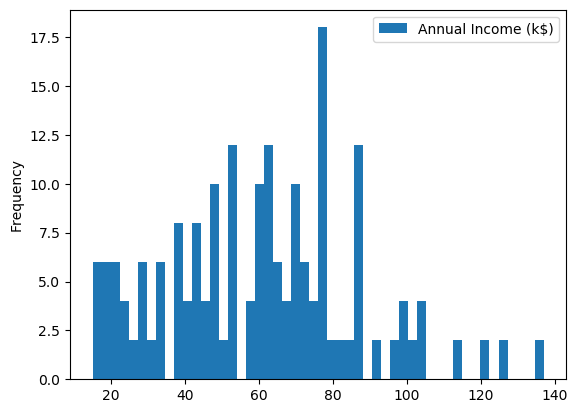

In [27]:
age_income.plot(kind='hist', bins=50)

Pokažimo još jedan važan tip grafa. To je box. Takva vrsta grafa pokazuje nam određene statistike. Za više informacija pogledajte: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.box.html

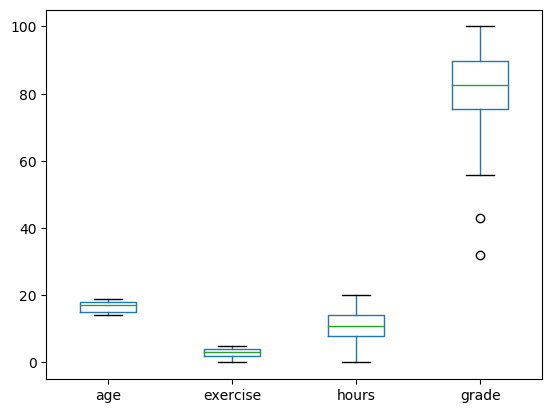

In [28]:
ocjene = pd.read_csv('ocjene.csv')
ocjene.plot(kind='box')

Prvo ćemo opisati izgled grafa. Graf se sastoji od "kutije" koja u sredini ima jednu crtu. Ovaj graf prikazuje statističke vrijednosti za svaku pojedinu varijablu (kolonu).

Točke koje stoje samostalno (kolona "grade" oko vrijednosti 40) su iznimke, ekstremi, odnosno *outlier* vrijednosti. Neke varijable ih nemaju.

Najniža crta predstavlja najmanju vrijednost (min) u skladu s time, a najviše crta prestavlja maksimalnu vrijednost (max).

Crta u sredini pravokutnika predstavlja vrijednost u sredini nakon što se podaci sortiraju (medijan).

Donja stranica pravokutnika predstavlja donji kvartil. To je 25% (jedna četvrtina) vrijednosti koje pripadaju u prvu četvrtinu. Dakle, kada skup podataka podijelimo na četiri jednaka skupa, dobijemo određene vrijednosti za granice između tih skupina. Q1 predstavlja skup svih vrijednosti koje su niže od granice između prve i druge četvrtine. Ovo je najjednostavniji opis kvartila.

Pretpostavljate da je onda gornja stranica četverokuta Q3 ili gornji kvartil, odnosno 75% vrijednosti neke varijable.

Postoji opcija "notch" za *box* tip grafa koju možemo uključiti, a koja dodaje zarez na pravokutniku na kojemu je medijan linija.

5. Vježba

Iskoristite opciju notch.

Sad ćemo napraviti malo veću vježbu s podacima o potresima.

In [29]:
earthquakes = pd.read_csv('earthquakes.csv')
earthquakes

,alert,cdi,code,detail,dmin,felt,gap,ids,mag,magType,...,sources,status,time,title,tsunami,type,types,tz,updated,url
0,NaN,NaN,37389218,https://earthquake.usgs.gov/fdsnws/event/1/que...,0.008693,NaN,85.0,",ci37389218,",1.35,ml,...,",ci,",automatic,1539475168010,"M 1.4 - 9km NE of Aguanga, CA",0,earthquake,",geoserve,nearby-cities,origin,phase-data,",-480.0,1539475395144,https://earthquake.usgs.gov/earthquakes/eventp...
1,NaN,NaN,37389202,https://earthquake.usgs.gov/fdsnws/event/1/que...,0.020030,NaN,79.0,",ci37389202,",1.29,ml,...,",ci,",automatic,1539475129610,"M 1.3 - 9km NE of Aguanga, CA",0,earthquake,",geoserve,nearby-cities,origin,phase-data,",-480.0,1539475253925,https://earthquake.usgs.gov/earthquakes/eventp...
2,NaN,4.4,37389194,https://earthquake.usgs.gov/fdsnws/event/1/que...,0.021370,28.0,21.0,",ci37389194,",3.42,ml,...,",ci,",automatic,1539475062610,"M 3.4 - 8km NE of Aguanga, CA",0,earthquake,",dyfi,focal-mechanism,geoserve,nearby-cities,o...",-480.0,1539536756176,https://earthquake.usgs.gov/earthquakes/eventp...
3,NaN,NaN,37389186,https://earthquake.usgs.gov/fdsnws/event/1/que...,0.026180,NaN,39.0,",ci37389186,",0.44,ml,...,",ci,",automatic,1539474978070,"M 0.4 - 9km NE of Aguanga, CA",0,earthquake,",geoserve,nearby-cities,origin,phase-data,",-480.0,1539475196167,https://earthquake.usgs.gov/earthquakes/eventp...
4,NaN,NaN,73096941,https://earthquake.usgs.gov/fdsnws/event/1/que...,0.077990,NaN,192.0,",nc73096941,",2.16,md,...,",nc,",automatic,1539474716050,"M 2.2 - 10km NW of Avenal, CA",0,earthquake,",geoserve,nearby-cities,origin,phase-data,scit...",-480.0,1539477547926,https://earthquake.usgs.gov/earthquakes/eventp...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9327,NaN,NaN,73086771,https://earthquake.usgs.gov/fdsnws/event/1/que...,0.018060,NaN,185.0,",nc73086771,",0.62,md,...,",nc,",reviewed,1537230228060,"M 0.6 - 9km ENE of Mammoth Lakes, CA",0,earthquake,",geoserve,nearby-cities,origin,phase-data,",-480.0,1537285598315,https://earthquake.usgs.gov/earthquakes/eventp...
9328,NaN,NaN,38063967,https://earthquake.usgs.gov/fdsnws/event/1/que...,0.030410,NaN,50.0,",ci38063967,",1.00,ml,...,",ci,",reviewed,1537230135130,"M 1.0 - 3km W of Julian, CA",0,earthquake,",geoserve,nearby-cities,origin,phase-data,scit...",-480.0,1537276800970,https://earthquake.usgs.gov/earthquakes/eventp...
9329,NaN,NaN,2018261000,https://earthquake.usgs.gov/fdsnws/event/1/que...,0.452600,NaN,276.0,",pr2018261000,",2.40,md,...,",pr,",reviewed,1537229908180,"M 2.4 - 35km NNE of Hatillo, Puerto Rico",0,earthquake,",geoserve,origin,phase-data,",-240.0,1537243777410,https://earthquake.usgs.gov/earthquakes/eventp...
9330,NaN,NaN,38063959,https://earthquake.usgs.gov/fdsnws/event/1/que...,0.018650,NaN,61.0,",ci38063959,",1.10,ml,...,",ci,",reviewed,1537229545350,"M 1.1 - 9km NE of Aguanga, CA",0,earthquake,",focal-mechanism,geoserve,nearby-cities,origin...",-480.0,1537230211640,https://earthquake.usgs.gov/earthquakes/eventp...


Uzet ćemo tip magnitude i magnitude i grupirati podatke po tipu magnitude i iscrtati box tip grafa. Opiste tipova možete pronaći na: https://www.usgs.gov/programs/earthquake-hazards/magnitude-types

Text(0, 0.5, 'Magnituda')

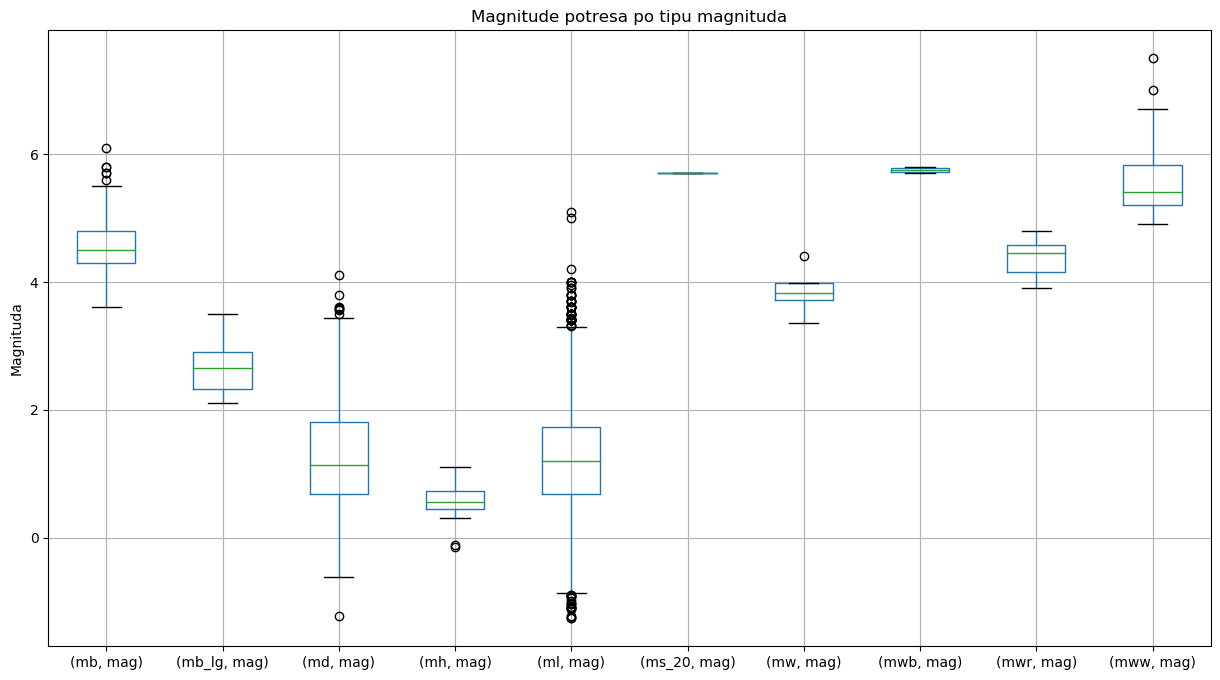

In [30]:
earthquakes[['mag', 'magType']].groupby('magType').boxplot(figsize=(15, 8), subplots=False)
plt.title('Magnitude potresa po tipu magnituda')
plt.ylabel('Magnituda')

X os prikazuje tipove magnituda.

Iskoristimo skup podataka o zemljotresima kako bismo se upoznali s još jednim često korištenim tipom prikaza podataka naziva "bar".

Prikažimo "bar" grafom koliko se puta dogodio zemljotres napojedinim lokacijama.

Text(0.5, 0, 'Potresi')

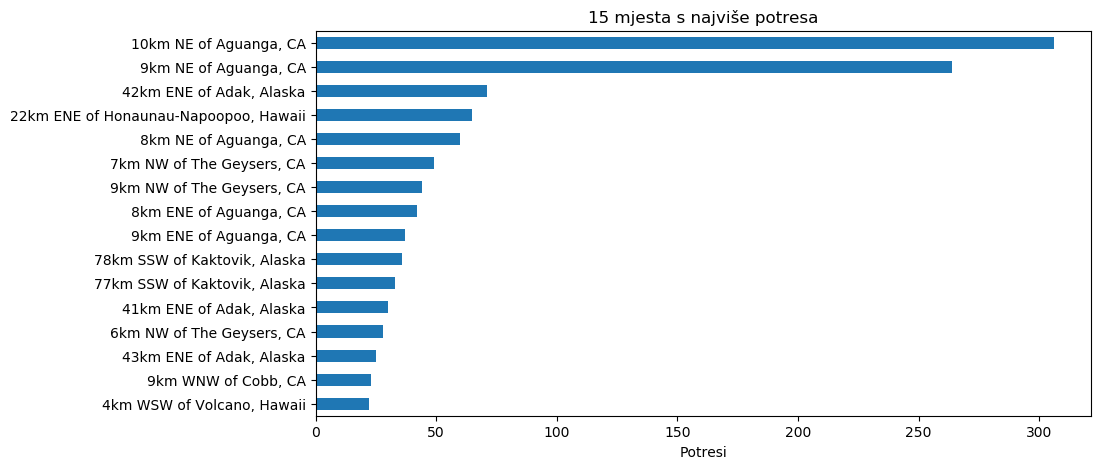

In [31]:
earthquakes.place.value_counts().iloc[15::-1,].plot(
    kind='barh',
    figsize=(10, 5),
    title='15 mjesta s najviše potresa'
)

plt.xlabel('Potresi')

Prvo ćemo pojasniti sintaksu. Umjesto *earthquakes\['place'\]* mi smo koristili *earthquakes.place*. Dakle, Pandas nam omogućava da pojedinim varijablama, odnosno kolonama pristupamo kao svojstvima nekog objekta.

Sljedeći korak je korištenje metode *value_counts()* kako bismo prebrojali vrijednosti za tu varijablu.

Indeks reda ili *iloc\[15::-1,\]* - *iloc* predstavlja "*index location*". Mi smo, zahvaljajući Python sintaksi, sa "*slice*" liste uzeli zadnjih 15 vrijednosti (obratite pažnju da je korak -1)  i onda smo pozvali metodu plot za iscrtavanje grafa tipa *'barh'*, a 'bar' iscrtava vertikalne.

Ovaj skup podataka ima i podatke o cunamijima.

Za cunami ćemo podatke morati malo drugačije izdvojiti. Prvo ćemo grupirati sve podatke po varijabli mjesta, zatim ćemo iz te skupine podataka nad kolonom "tsunami", pokrenuti metodu "*sum()*" kako bismo zbrojili sve cunamije na toj lokaciji i na kraju sortirali vrijednosti te izabrali samo zadnjih 15. Naravno, na kraju smo pomoću *.plot()* metode iscrtali te podatke.

Text(0.5, 0, 'Cunami')

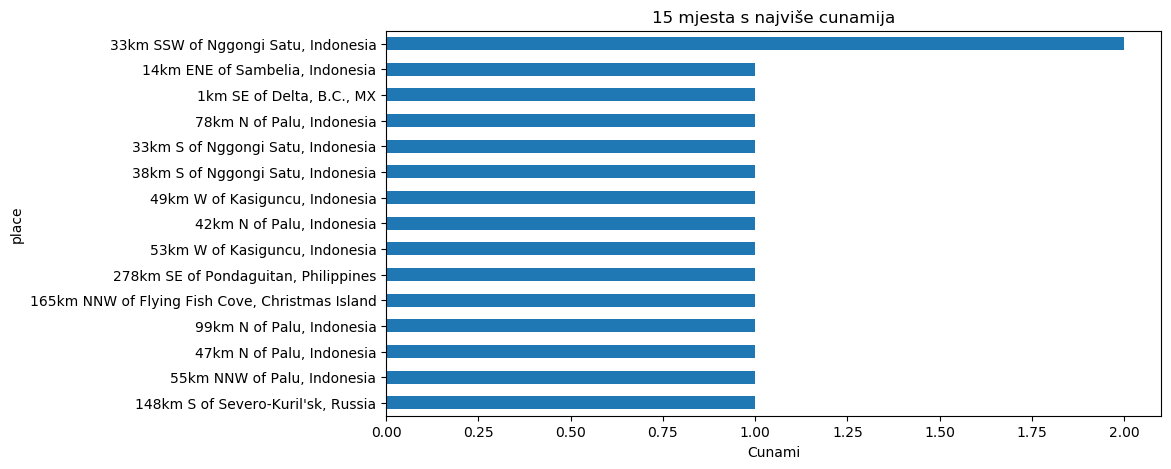

In [32]:
earthquakes.groupby('place').tsunami.sum().sort_values().iloc[-15:,].plot(
    kind='barh',
    figsize=(10, 5),
    title='15 mjesta s najviše cunamija'
)

plt.xlabel('Cunami')

Ovo je odličan primjer zbog čega podatke trebamo prilagoditi prije vizualizacije. Isto tako, služi kao dokaz tomu kako ćemo obradu podataka raditi paralelno s vizualizacijom jer ponekad otkrijemo da ne možemo koristiti podatke pa ih onda još jednom "presložimo" kako bi nam bili korisniji.

Problem u gornjem grafu je taj što imamo jako puno PONAVLJANJA, koja se za Indoneziju drugačije tretiraju. Odnosno cunamiji bi u Indoneziji, u našem slučaju, trebali biti objedinjeni pod jednom vrijednosti. Ponekad će biti korisno znati distribuciju po regijama unutar neke zemlje, recimo Indonezije.

Vratimo se na naš primjer. Pokušajmo pomoću Pythona preimenovati vrijednosti za mjesta tako da ih učinimo nama korisnijima. Koristit ćemo metodu *.replace()* unutar "*str*" objekta tako što ćemo proći kroz sve vrijednosti u koloni "place", počistiti "višak" informacija i sve pohraniti u novu kolonu.

**NAPOMENA:  ako trebate mijenjati podatke unutar skupa podatka, najbolje je kreirati novu kolonu u koju ćete pohraniti nove vrijednosti.**

Koristiti ćemo i "REGEX - Regular expressions" argument koji nam omogućava provjeru znakova unutar nekog teksta na osnovi predefiniranog predloška. Regex se jako često koristi u programiranju za kontrolu unosa podataka. Kada u neku formu unosite podatke o broju telefona ili email adresi, regex definira kako će izgledati oblik broja telefona pa nećete moći unijeti broj u obliku 00385011234567 nego kao +385 (0)1 1234 567. Više detalja na poveznici: https://docs.python.org/3/howto/regex.html.

Osim *regex=True* koristimo i oznaku *r* ispred početka string varijable. Ovo malo slovo *r* označava "*row string*". Više detalja u Python dokumentaciji: https://docs.python.org/3/reference/lexical_analysis.html#string-and-bytes-literals.

Prvo ćemo zamijeniti praznim stringom sve:
- *r'.* *of ', ''* - iza točke što ima "*of*"
- *'the ', ''* - što počinje s *the*. 

Zatim ćemo promijeniti skraćenice u pune nazive za:
- California
- Nevada
- Mexico. 

Preimenovati neke lokacije:
- Fiji Islands u Fiji.

Na kraju, pomoću *.strip()* metode, maknite preostale prazne znakove (primjer: razmaci koji su ostali uz riječi).

Dodatno ćemo ispisati mjesta koja smo dobili kao provjeru.

In [33]:
earthquakes['mjesta'] = earthquakes.place.str.replace(
    r'.* of ', '', regex=True
).str.replace(
    'the ', ''
).str.replace(
    r'CA$', 'California', regex=True
).str.replace(
    r'NV$', 'Nevada', regex=True
).str.replace(
    r'MX$', 'Mexico', regex=True
).str.replace(
    r' region$', '', regex=True
).str.replace(
    'northern ', ''
).str.replace(
    'Fiji Islands', 'Fiji'
).str.replace(
    r'^.*, ', '', regex=True
).str.strip()

earthquakes.mjesta.sort_values().unique()

array(['Afghanistan', 'Alaska', 'Argentina', 'Arizona', 'Arkansas',
       'Ascension Island', 'Australia', 'Azerbaijan', 'Balleny Islands',
       'Barbuda', 'Bolivia', 'British Virgin Islands', 'Burma',
       'California', 'Canada', 'Carlsberg Ridge',
       'Central East Pacific Rise', 'Central Mid-Atlantic Ridge', 'Chile',
       'China', 'Christmas Island', 'Colombia', 'Colorado', 'Costa Rica',
       'Dominican Republic', 'East Timor', 'Ecuador', 'El Salvador',
       'Fiji', 'Greece', 'Greenland', 'Guam', 'Guatemala', 'Haiti',
       'Hawaii', 'Honduras', 'Idaho', 'Illinois', 'India',
       'Indian Ocean Triple Junction', 'Indonesia', 'Iran', 'Iraq',
       'Italy', 'Jamaica', 'Japan', 'Kansas', 'Kentucky',
       'Kermadec Islands', 'Kuril Islands', 'Kyrgyzstan', 'Martinique',
       'Mauritius', 'Mayotte', 'Mexico', 'Mid-Indian Ridge', 'Missouri',
       'Montana', 'Nevada', 'New Caledonia', 'New Hampshire',
       'New Mexico', 'New Zealand', 'Nicaragua', 'North Carolina',


Probajmo sada iscrtati isti graf, ali nad novom kolonom u kojoj smo preuredili nazive mjesta.

Text(0.5, 0, 'Cunami')

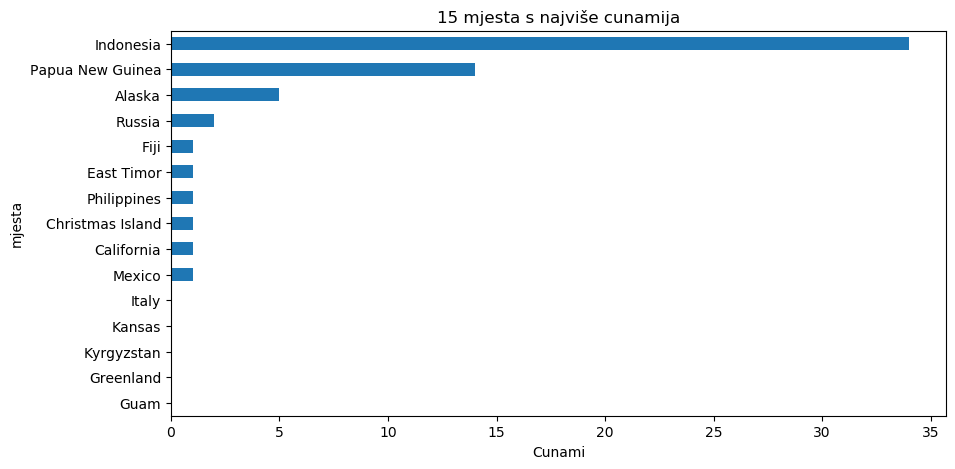

In [34]:
earthquakes.groupby('mjesta').tsunami.sum().sort_values().iloc[-15:,].plot(
    kind='barh',
    figsize=(10, 5),
    title='15 mjesta s najviše cunamija'
)

plt.xlabel('Cunami')

Prikažimo i pie (pita) tip grafa.

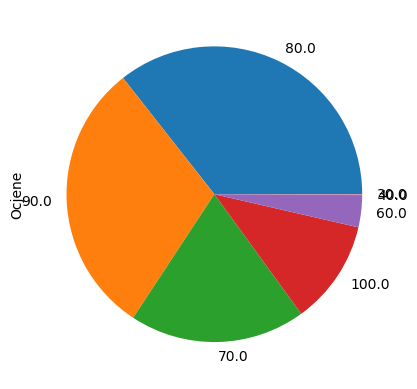

In [68]:
ocjene_only_grades = ocjene[['grade']].copy()
# Sto smo napravili u iducoj liniji?
ocjene_only_grades['Ocjene'] = round(ocjene_only_grades['grade'] / 10, 0) * 10
ocjene_only_grades['Ocjene'].value_counts().plot(kind='pie')